1.‎ 첨부된 파일 'NGC5055_rotmod.dat'은 9.9Mpc 거리에 있는 NGC5055 은하의 관측된 회전속도 곡선과 뉴턴모형이 예측하는 속도 곡선들을 포함하고 있다. R은 은하 중심으로부터의 거리를 나타내며 kpc(kilo parsec) 단위로 주어졌다. Vobs와 errV는 관측된 회전속력과 그 오차를 나타낸다. Vdisk와 Vgas는 각각 관측된 별원반과 가스원반의 질량분포에 의해서 예측되는 원운동 속력들을 나타낸다. 여기서 Vdisk는 질량대광도비를 $\Upsilon = 1$로 가정하고 계산한 값이다. (이 은하의 경우 Vbul은 0이므로 고려하지 않아도 된다.) 뉴턴역학이 관측된 모든 질량 분포의 합에 대해서 예측하는 회전속력은 $V_{bar} = \sqrt{\Upsilon {V_{disk}}^2 + {V_{gas}}^2}$로 주어진다. 여기서 $\Upsilon$는 미지수이다. 은하회전속도 곡선을 뉴턴모형과 MOND모형으로 fitting해보자. [총 50점]

(1) $\chi^2 = \sum_{i=1}^{N} \left (\frac{V_{obs} (R_{i}) - V_{bar} (R_{i})} {\sigma_{V} (R_{i})}\right)^2$을 minimize하는 코드를 짜고 실행하여 $\Upsilon$값을 구하고, 이 값에 대해서 Vbar를 그리고 Vobs와 비교하라. 서로 잘 일치하는가? 카이제곱의 최솟값은 얼마인가? (20점)

chi^2을 최소화하는 최적의 Upsilon: 0.6512851285
chi^2의 최소값: 41659.7682027389


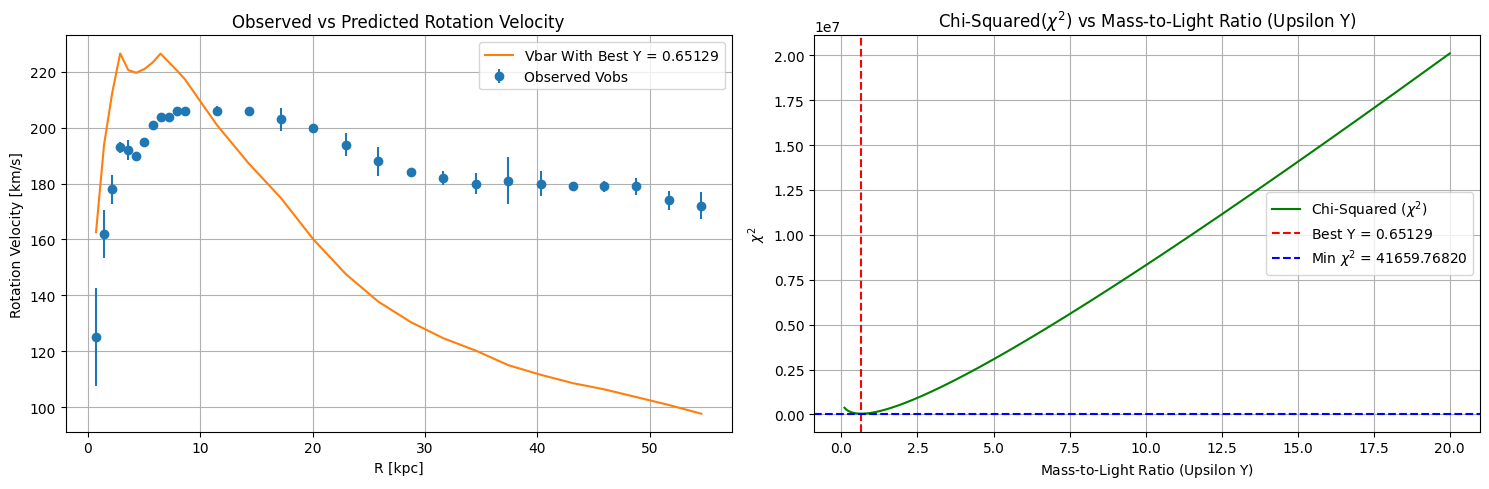

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 데이터 파일을 np.loadtxt로 불러오기 - 파일을 다른 형태로 불러오려 시도해본 것들은, 문제 풀이를 마친 뒤 맨 아래에 번외 파트로 작성해두었습니다.
# 문제에서 Vbul은 0이므로 고려하지 않아도 된다고 했고, SBdisk랑 SBbul는 문제 풀이에서 사용하지 않을 것 같아서, 그냥 *_로 Vbul뒤로 불필요한 열을 무시하기 위해 사용
R, Vobs, errV, Vgas, Vdisk, *_ = np.loadtxt('NGC5055_rotmod.dat', unpack=True)

#Upsilon 값을 찾기 위한 Upsilon 그리드 생성
#코드에서 Upsilon 값의 범위를 0에서 20으로 설정하고, 10000개의 점을 만들었는데, 그 이유는 WIKIPEDIA의 'Mass-to-light ratio' 문서에서 아래와 같은 문장을 보았기 때문이다.
#Typical mass-to-light ratios for galaxies range from 2 to 10 ϒ☉ while on the largest scales, the mass to light ratio of the observable universe is approximately 100 ϒ☉, in concordance with the current best fit cosmological model.
#앞 문장을 한국어로 번역하자면, Upsiilon은 "은하의 질량-광도 비율을 나타내며, 일반적으로 2에서 10 사이의 값을 가집니다. 현재 우주의 질량-광도 비율은 약 100 ϒ☉로, 이는 현재의 최적 우주론 모델과 일치합니다."정도가 될 것이다.
#일반적으로 2에서 10 사이의 값을 가지므로, Upsilon의 범위를 0.1에서 20으로 설정하고, 10000개의 점을 만들어서 Upsilon 값을 찾는 것이 적절할 것 같다고 생각했다.
Upsilon_search = np.linspace(0.1, 20, 10000) # Upsilon 값의 범위 설정 - 처음값이 0이 아니라 0.1로 설정한 이유는, Upsilon이 0이면 질량-광도 비율이 없다는 의미이므로, 실제로는 존재하지 않는 값이기 때문이다.
chi_square_search = []

# 관측된 회전 속도랑 예측 모델 회전 속도의 차이를 최소화하는 Upsilon 값을 찾기 위한 for문 loop 돌리기
for Upsilon in Upsilon_search:
    Vbar = np.sqrt(Upsilon * Vdisk**2 + Vgas**2)
    chi_square = np.sum(((Vobs - Vbar) / errV) ** 2)
    chi_square_search.append(chi_square)

# chi_square_search에서 최소값을 찾고, 그에 해당하는 Upsilon 값을 찾기
chi_square_search = np.array(chi_square_search) # chi_square_search를 numpy 배열로 변환하여 연산 속도를 높음, 그리고 np.argmin을 사용하기 위해서도 변환이 필요함.
min_idx = np.argmin(chi_square_search) # 최적의 Upsilon 값을 찾기 위해 chi_square_search에서 최소값의 인덱스를 찾음, np.argmin은 배열에서 최소값의 인덱스를 반환하는 함수이다.
Upsilon_nice = Upsilon_search[min_idx]
chi_square_min = chi_square_search[min_idx]

print(f"chi^2을 최소화하는 최적의 Upsilon: {Upsilon_nice:.10f}")
print(f"chi^2의 최소값: {chi_square_min:.10f}")

Vbar_nice = np.sqrt(Upsilon_nice * Vdisk**2 + Vgas**2) # 최적의 Upsilon 값을 사용하여 예측 모델 회전 속도 계산


# 결과를 시각화하기 위한 그래프 그리기
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# 첫 번째 그래프: 관측된 회전 속도와 예측 뉴턴 모델 회전 속도 비교
axs[0].errorbar(R, Vobs, yerr = errV, fmt = 'o', label = 'Observed Vobs') # 오차를 포함한 관측된 회전 속도
axs[0].plot(R, Vbar_nice, '-', label = f'Vbar With Best $\\Upsilon$ = {Upsilon_nice:.5f}') # 최적의 Upsilon 값을 사용한 예측 모델 회전 속도 | 최적값이기는 하니까, 출력값에서 이름을 Nice에서 Best로 바꿨다.
axs[0].set_title('Observed vs Predicted Rotation Velocity')
axs[0].set_xlabel('R [kpc]')
axs[0].set_ylabel('Rotation Velocity [km/s]')
axs[0].legend()
axs[0].grid(True)

# 두 번째 그래프: chi-squared 값과 Upsilon 값의 관계
axs[1].plot(Upsilon_search, chi_square_search, 'g-', label = 'Chi-Squared ($\chi^2$)') # Upsilon 값에 따른 chi-squared 값의 변화
axs[1].axvline(x = Upsilon_nice, color = 'r', linestyle = '--', label = f'Best $\\Upsilon$ = {Upsilon_nice:.5f}') # 최적의 Upsilon 값을 수직선으로 표시 | 최적값이기는 하니까, 출력값에서 이름을 Nice에서 Best로 바꿨다.
#$\\Upsilon$부분에서는 내가 latex를 사용할 때, \를 두 번 사용했는데, 그 이유는 \ 하나만 쓰면 오류가 나기 때문이다. 이 오류의 원인은 파이썬에서 \u 또는 \U로 시작하면 뒤에 오는 숫자를 유니코드로 해석하려고 하기 때문이라고 한다.
axs[1].axhline(y = chi_square_min, color = 'b', linestyle = '--', label = f'Min $\chi^2$ = {chi_square_min:.5f}') # 최소 chi^2 값을 수평선으로 표시
axs[1].set_title('Chi-Squared($\chi^2$) vs Mass-to-Light Ratio (Upsilon $\\Upsilon$)')
axs[1].set_xlabel('Mass-to-Light Ratio (Upsilon $\\Upsilon$)')
axs[1].set_ylabel('$\chi^2$')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

.



.

[비교 분석]

왼쪽의 그래프를 통해, Vbar를 주황색으로 그렸고, Vobs를 파란색 점으로 오차 막대를 포함하여 그려 보았다. 이럴 때, 둘을 비교해 보면 서로 잘 일치하지 않음을 확인할 수 있다.

R이 약 10kpc보다 작은 경우에는(R < 10kpc), 주황색 선인 Vbar와 파란색 점으로 나타낸 Vobs가 어느 정도 비슷한 경향을 띄는 것처럼 보이는데, 이곳에서도 이론적 예측값인 Vbar가 관측값 Vobs보다 전반적으로 높게 나타나는 것을 볼 수 있고, 오차 막대를 고려해도 서로가 일치를 보인다고 말하기 어렵다.

R이 약 10kpc보다 큰 경우에는(R > 10kpc), 둘의 불일치가 훨씬 커진다. 관측값인 Vobs은 은하 중심으로부터의 거리 R이 커져도 속도가 거의 줄어들지 않는 모습을 보이지만, 이론적 예측값인 Vbar는 은하 중심으로부터의 거리 R이 커질수록 속도가 급격하게 줄어드는 모습을 보여준다. 50kpc 정도에서는 회전 속력 Rotation Velocity가 100km/s에 인접하게 된다.

.



.

(2) 비교적 간단한 MOND 모형을 fitting해 보자. 주어진 $V_{bar}(R_i)$에 대해서 모형의 예측치는 $V_{MOND}(R_i) = \sqrt{\nu(g_N/a_0, e)}V_{bar}(R_i)$로 주어진다. 이 식에 다음 함수가 사용된다. $\nu(z,e) \equiv \frac{1}{2} - \frac{A_e}{z} + \sqrt{\left( \frac{1}{2} - \frac{A_e}{z}\right)^2 + \frac{B_e}{z}}$, 여기서 $z \equiv \frac{g_{N}}{a_{0}},\,A_{e} \equiv e(1+0.5e)/(1+e),\,B_{e} \equiv 1+e$, 그리고 $g_{N} = g_{N}(R_i) = (V_{bar}(R_i))^2/Ri,\,a_{0} = 1.2 \times 10^{-10}ms^{-2}$ (고정된 가속도 값).

이제 $\chi^2 = \sum_{i=1}^{N} \left (\frac{V_{obs} (R_{i}) - V_{bar} (R_{i})} {\sigma_{V} (R_{i})}\right)^2$을 minimize하는 코드를 짜고 실행하여 $\Upsilon$값과 $e$값을 구하고 이 값에 대해서 $V_{MOND}$를 그리고 $V_{obs}$와 비교하라. 서로 잘 일치하는가? 카이제곱의 최솟값은 얼마인가?

Upsilon와 e의 범위를 설정할 때, 여러 시도를 해보았다. 우선 Upsilon부터 이야기하자면 처음에는 (1)에서와 마찬가지로, (0.1, 20, 10000)으로 하였을 때에는, 최적의 Upsilon: 0.350765076507651, chi^2 최소값: 61.835029274561336 결과가 나왔고 코드 실행 1m 5.4s로, (1) 문제에서는 0.3s가 걸린 것에 비해 시간도 오래 걸렸다. 그래서 범위랑, 생성하는 점의 개수를 조정하며 엄청나게 많이 해봤는데, 최종적으로는 범위도 범위인데, 점의 개수 또한 중요하다는 것을 알게 되었다. 얼마나 촘촘하냐에 따라서, 일정 부분 이상을 넘어간 뒤로는 비슷했지만 $\chi^2$의 값이 더 작은 값들을 갖게 되었다. 그리고 찾아지는 Upsilon 값이 0.350765076507651이기도 하니, 굳이 20까지는 할 필요가 없다고 생각해서, (0.1, 1, 10000)으로 하였다.


개인적으로 e의 범위를 설정할 때에 많은 고민을 하였다. 그냥 이것저것 넣어보면서 해보기도 했지만, 최종적으로는 WIKIPEDIA의 'Modified Newtonian dynamics' 문서를 참고했다. 이곳의 내용에 따르면, MOND 보간 함수는 가속도가 큰 영역에서는 뉴턴역학으로 향하고($\mu → 1$), 가속도가 작은 영역에서는 MOND 효과가 강하게 작용하도록 ($\mu → x$)가 된다고 한다. 이것을 지금 풀고 있는 이 문제에 적용해 보면, 주어진 MOND 보간 함수 $\nu(z,e)$에서 e는 뉴턴역학이랑 MOND 사이를 조절하는 전이 강도로, 작은 e는 급격한 전이를, 큰 e는 완만한 전이를 유도한다. 그래서 나는 MOND 효과를 위해서 가속도가 작은 영역을 택했고, e 값을 [0.001, 1]로 설정했다.

chi^2을 최소화하는 최적의 Upsilon: 0.349549549549550
최적의 e: 0.038000000000000
chi^2 최소값: 61.414798988820692


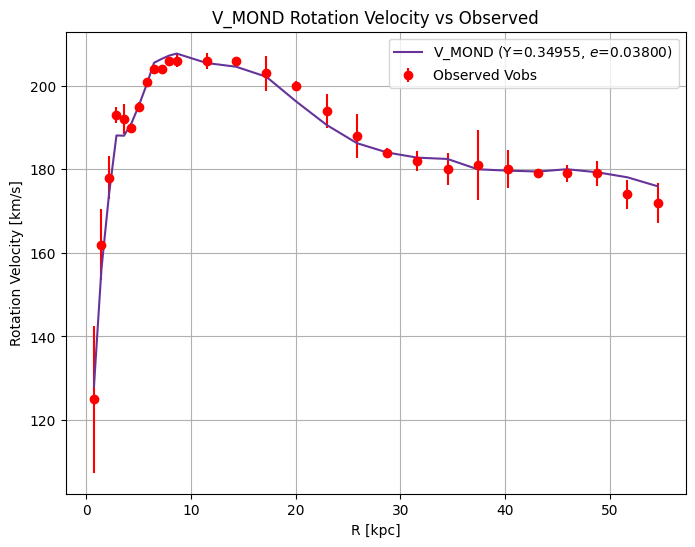

In [6]:
a0 = 1.2e-10 # 문제에서 주어진 고정된 가속도 a0값
kpc_to_meter = 3.08567758128e19 # UnitConverters.net 사이트 참고해서, kpc를 m로 바꾸는 수를 결정함.
R_meter = R * kpc_to_meter # R을 kpc에서 m로 바꿈


# Upsilon이랑 e값의 범위 설정
Upsilon_search = np.linspace(0.1, 1, 1000)
e_search = np.linspace(0.001, 1, 1000) # 이 부분을 e_search = np.logspace(-3, 0, 1000)로 바꾸어서 코드를 돌려보기도 했는데 상관이 없었다. 그런데 크게 차이가 안 나기에, 그냥 linspace를 사용했다.


# Upsilon이랑 e값을 찾기 위해서 meshgird 생성
# (1)번 문제에서는 파라미터가 Upsilon 하나였기 때문에 바로 단일 for문 loop를 돌렸지만, (2) 문제에서는 최적화해야 할 파라미터가 두 개(Upsilon, e)이기 때문에, (Upsilon, e) 조합으로 만들려고 우선 meshgrid를 사용해서 모든 조합을 격자 형태로 만들어뒀다.
# 그리고 행에는 Upsilon, 열에는 e를 지정해줬다.
U_grid, e_grid = np.meshgrid(Upsilon_search, e_search, indexing='ij')

# 그리고 이제 뒤에 for문에서는 두 파라미터의 조합 (\Upsilon, e)을 하나씩 다루기 위해서, meshgrid로 만든 2차원 격자를, .ravel()를 써서 1차원 배열로 바꾸었다.
U_flat = U_grid.ravel()
e_flat = e_grid.ravel()


# 두 파라미터에 대한 조합의 갯수
N = U_flat.size

# 처음에는 np.zeros를 사용할까 했는데 np.zeros는 처음에 전부 0으로 초기화해서 만드는 데에 반면, np.empty는 초기화 없이 빈 메모리 공간만 할당해서 연산 속도가 조금 더 빠르기 때문에 np.empty를 썼다.
# 그런데 이 문제에서는 속도 차이가 전혀 안 나긴 했지만, 공부를 해본 김에 써보았다.
chi_square_search = np.empty(N)


# Upsilon 값이랑 e값을 찾기 위한 for문 loop 돌리기
for idx in range(N):
    U = U_flat[idx]
    e = e_flat[idx]

    Vbar = np.sqrt(U * Vdisk**2 + Vgas**2)
    gN = (Vbar * 1000)**2 / R_meter # 지금 문제에서, z = g_{N}/a_{0}이라고 했는데, a_0의 단위가 m/s^-2이니까, m 단위로 맞추려고, Vbar의 km/s 단위를 m로 바꿈.

    Ae = e * (1 + 0.5 * e) / (1 + e)
    Be = 1 + e

    z = np.clip(gN / a0, 1e-5, None)  # z의 값이 1e-5보다 작으면 버리도록 설정을 해뒀는데, 그 이유는 지금 $\nu(z,e) \equiv \frac{1}{2} - \frac{A_e}{z} + \sqrt{\left( \frac{1}{2} - \frac{A_e}{z}\right)^2 + \frac{B_e}{z}}$
    # 이 식을 보면 분모들에 z값이 위치해있는데, z가 심각하게 많이 작아지면 1/z가 무한대로 발산할 수도 있어서, 혹시 몰라서 해뒀다. 근데 이 코드에서 z의 최솟값이 얼마나 나올까 궁금해서 print(f"z의 최솟값: {z.min():.15e}")로 찾아봤는데, z의 최솟값: 1.453133336374543e-02가 나왔다.
    # 그래서 하한값을 둬서 꼭 z값을 걱정할 필요는 없었지만, 공부하는 차원에서 했다.
    nu = 0.5 - Ae/z + np.sqrt((0.5 - Ae/z)**2 + Be/z)
    Vmond = np.sqrt(nu) * Vbar

    chi_square = np.sum(((Vobs - Vmond) / errV)**2)
    chi_square_search[idx] = chi_square

# chi^2가 최소가 되는 위치 찾기
nice_idx = np.argmin(chi_square_search)
Upsilon_nice = U_flat[nice_idx]
e_nice = e_flat[nice_idx]
chi_square_min = chi_square_search[nice_idx]



print(f"chi^2을 최소화하는 최적의 Upsilon: {Upsilon_nice:.15f}")
print(f"최적의 e: {e_nice:.15f}")
print(f"chi^2 최소값: {chi_square_min:.15f}")


# 이제 최적의 \Upsilon이랑, e값을 찾았으니까 이 둘의 조합에서의 MOND 은하 회전 속도 곡선을 그리기 위해서 다른 값들을 계산하기
Vbar_nice = np.sqrt(Upsilon_nice * Vdisk**2 + Vgas**2)
gN_nice = (Vbar_nice * 1000)**2 / R_meter
Ae_nice = e_nice * (1 + 0.5 * e_nice) / (1 + e_nice)
Be_nice = 1 + e_nice
z_nice = np.clip(gN_nice / a0, 1e-5, None) # z_nice를 계산할 때도 하한값을 설정해뒀다.
nu_nice = 0.5 - Ae_nice/z_nice + np.sqrt((0.5 - Ae_nice/z_nice)**2 + Be_nice/z_nice)
Vmond_nice = np.sqrt(nu_nice) * Vbar_nice

# 시각화
plt.figure(figsize=(8,6))
plt.errorbar(R, Vobs, yerr = errV, fmt = 'o', color = 'red', label = 'Observed Vobs')
plt.plot(R, Vmond_nice, '-', color = 'rebeccapurple', label = f'V_MOND ($\\Upsilon$={Upsilon_nice:.5f}, $e$={e_nice:.5f})')
plt.xlabel('R [kpc]')
plt.ylabel('Rotation Velocity [km/s]')
plt.title('V_MOND Rotation Velocity vs Observed')
plt.legend()
plt.grid(True)
plt.show()

.



.

[비교 분석]

왼쪽의 그래프를 통해, $V_{MOND}$를 rebeccapurple색으로 그렸고, $V_{obs}$를 빨간색 점으로 오차 막대를 포함하여 그려 보았다. 이를 통해, 둘을 비교해 보면 (1)에서의 결과에 비해 MOND 모델이 관측 데이터와 비교적 잘 일치하고 있음을 확인할 수 있다.

먼저 R이 약 10kpc보다 작은 경우에는(R < 10kpc), 그리고 특히 R이 약 5kpc 정도 생각되는 지점에서는 $V_{MOND}$곡선이 관측 데이터인 $V_{obs}$의 오차 막대 안을 거의 완벽하게 통과하고 있음을 알 수 있고, MOND 모델이 은하 중심부의 회전 속도를 잘 설명하고 있음을 알 수 있다.

또한 R이 약 10kpc보다 큰 경우 또한(R > 10kpc), 둘의 불일치 정도가 (1)에서는 급격히 벌어진 것과 상반되게, 대체로 준수한 일치도를 유지하고 있다. 또한 (1)에서는 뉴턴모형의 이론적 예측값이었던 $V_{bar}$가 은하 중심으로부터의 거리 R이 커질수록 속도가 급격하게 줄어드는 모습을 보였지만, (2)을 통해 도출한 $V_{MOND}$에서는 거리 R이 커짐에도 속도가 급격하게 줄어드는 모습을 보이지 않고 관측 데이터인 Vobs와 함께 나란하게 평탄한 형태를 보이고 있다.

이러한 결과는 MOND의 중력 보간 함수가 낮은 가속도 영역에서 작용하여 중력을 증폭시키는 효과를 잘 구현했음을 보여준다. 결과적으로 MOND 모델은 복잡한 암흑물질의 가정을 도입하지 않고도, 관측값에서 확인할 수 있는 은하 외곽의 평탄한 회전 곡선 현상을 잘 설명할 수 있음을 알려준다.

그리고 $\chi^2$값의 최솟값 또한 61.414798988820692으로, (1)에서 얻은 $\chi^2$값의 최솟값 41659.7682027389보다 훨씬 작게 나왔는데, 이는 MOND 모델이 뉴턴 모델에 비해 관측값을 훨씬 더 잘 설명한다는 것을 의미한다.

.



.

아래에서는 최종적으로 얻은 (1)과 (2)에서의 결과를 함께 나열하면 좋을 것 같아서 그려보았다.

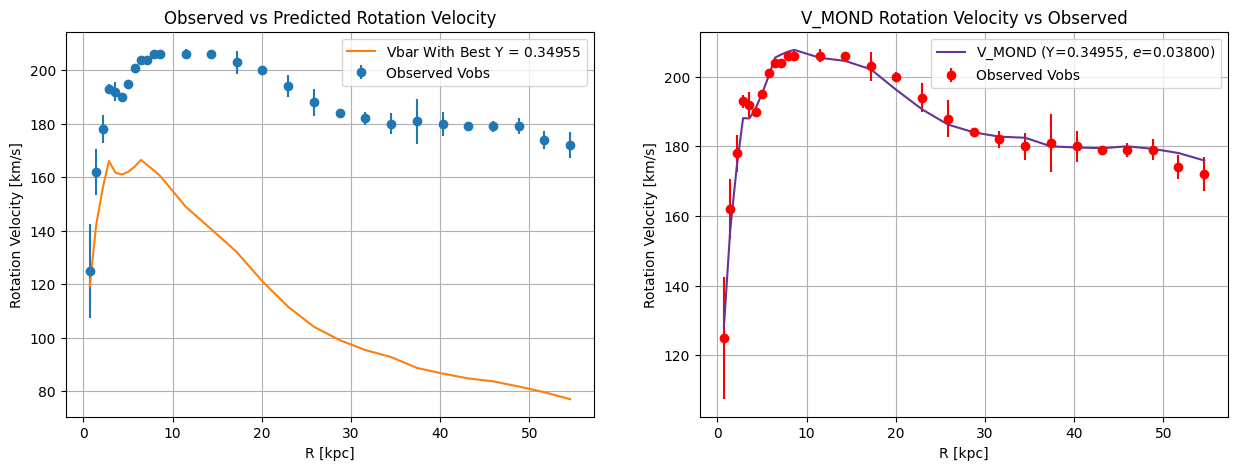

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# 첫 번째 그래프: 관측된 회전 속도와 예측 뉴턴 모형 회전 속도 비교
axs[0].errorbar(R, Vobs, yerr = errV, fmt = 'o', label = 'Observed Vobs') # 오차를 포함한 관측된 회전 속도
axs[0].plot(R, Vbar_nice, '-', label = f'Vbar With Best $\\Upsilon$ = {Upsilon_nice:.5f}') # 최적의 Upsilon 값을 사용한 예측 모델 회전 속도 | 최적값이기는 하니까, 출력값에서 이름을 Nice에서 Best로 바꿨다.
axs[0].set_title('Observed vs Predicted Rotation Velocity')
axs[0].set_xlabel('R [kpc]')
axs[0].set_ylabel('Rotation Velocity [km/s]')
axs[0].legend()
axs[0].grid(True)

axs[1].errorbar(R, Vobs, yerr = errV, fmt = 'o', color = 'red', label = 'Observed Vobs')
axs[1].plot(R, Vmond_nice, '-', color = 'rebeccapurple', label = f'V_MOND ($\\Upsilon$={Upsilon_nice:.5f}, $e$={e_nice:.5f})')
axs[1].set_title('V_MOND Rotation Velocity vs Observed')
axs[1].set_xlabel('R [kpc]')
axs[1].set_ylabel('Rotation Velocity [km/s]')
axs[1].legend()
axs[1].grid(True)
plt.show()

.



.

번외 1 - (1)_ver.2 - 기본 인덱싱 방법으로 데이터 파일 불러오기 - SBdisc랑 SBbul은 안 쓰길래 안 불러왔다.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('NGC5055_rotmod.dat')
R = data[:, 0]
Vobs = data[:, 1]
errV = data[:, 2]
Vgas = data[:, 3]
Vdisk = data[:, 4]

.


.

번외 1 - (1)_ver.3 - pandas 이용하여 데이터 파일 불러오기

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('NGC5055_rotmod.dat',
    sep=r'\s+', # 이번 파일은 csv파일이 아니라서 ',(콤마)'로 구분이 되어 있지 않길래 공백을 구분자로 사용
    comment='#', # 주석처리된 부분은 무시
    header=None, # 헤더가 주석처리된 부분인데, 위에 부분에서 내가 무시하기로 했기 때문에 없어져서 None으로 설정
    names=['R', 'Vobs', 'errV', 'Vgas', 'Vdisk', 'Vbul', 'SBdisk', 'SBbul'])